### 030

In [1]:
import os

source_dir = '/home/work/hocheol_dir/workspace/datasets/_origin_data/030_data/data'
dest_dir = '/home/work/hocheol_dir/datasets/v0.2_data/wrinkle/030_data/data'

exts = set()

for root, dirs, files in os.walk(source_dir):
    for file in files:
        exts.add(file.split('.')[-1])

print(exts)

{'jpg', 'JPG'}


In [2]:
import pandas as pd
image_df = pd.DataFrame(os.listdir(source_dir), columns=['filename'])
image_df['path'] = image_df['filename'].apply(lambda x:os.path.join(source_dir, x))
image_df['filename'] = image_df['filename'].apply(lambda x:os.path.splitext(x)[0])
image_df.head()

,filename,path
0,0001_face,/home/work/hocheol_dir/workspace/datasets/_ori...
1,0002_face,/home/work/hocheol_dir/workspace/datasets/_ori...
2,0003_face,/home/work/hocheol_dir/workspace/datasets/_ori...
3,0004_face,/home/work/hocheol_dir/workspace/datasets/_ori...
4,0005_face,/home/work/hocheol_dir/workspace/datasets/_ori...


In [7]:
label_df = pd.read_csv('/home/work/hocheol_dir/workspace/datasets/v0.2_data/wrinkle/NIA_Korean_wholebody_wrinkle_250710.csv')
label_df.rename(columns={'periroal':'perioral'}, inplace=True)
merged_df = pd.merge(image_df, label_df, on='filename', how='inner')
label_df

,filename,성별,나이,forehead,right_eye,left_eye,nasolabial,perioral,right_vol,left_vol
0,0001_face,남자,9,NaN,0,0.0,0,0.0,0.0,0
1,0002_face,남자,9,0.0,0,0.0,0,0.0,0.0,0
2,0003_face,남자,16,NaN,1,0.0,0,0.0,0.0,0
3,0004_face,남자,17,NaN,1,1.0,0,0.0,0.0,0
4,0005_face,남자,17,NaN,0,0.0,0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...
1619,1976_face,여자,69,3.0,2,2.0,4,3.0,1.0,1
1620,1977_face,여자,70,2.0,2,2.0,3,2.0,2.0,2
1621,1978_face,여자,67,NaN,3,3.0,4,2.0,2.0,2
1622,1979_face,여자,70,NaN,3,3.0,3,3.0,1.0,1


In [ ]:
import sys
sys.path.append("/home/work/hocheol_dir/workspace/datasets/v0.2_data/wrinkle")
from face_crop_wrinkle_250710 import wrinkle_preprocess
import cv2
import math
from tqdm import tqdm

sectors = ['forehead', 'right_eye', 'left_eye', 'nasolabial', 'perioral', 'right_vol', 'left_vol']

for i, row in tqdm(merged_df.iterrows()):
    path = row['path']
    values = wrinkle_preprocess(path)

    cropped_data = dict(zip(sectors, values))

    for sector, cropped_image in cropped_data.items():
        # print(sector)
        if math.isnan(row[sector]):
            print(f"Skipping {sector} for {row['filename']} due to NaN value.")
            continue
        else:
            # print(sector, row[sector])
            cv2.imwrite(os.path.join(dest_dir, f"{sector}_{row['filename']}.jpg"), cropped_image)

ModuleNotFoundError: No module named 'face_crop_wrinkle_250710'

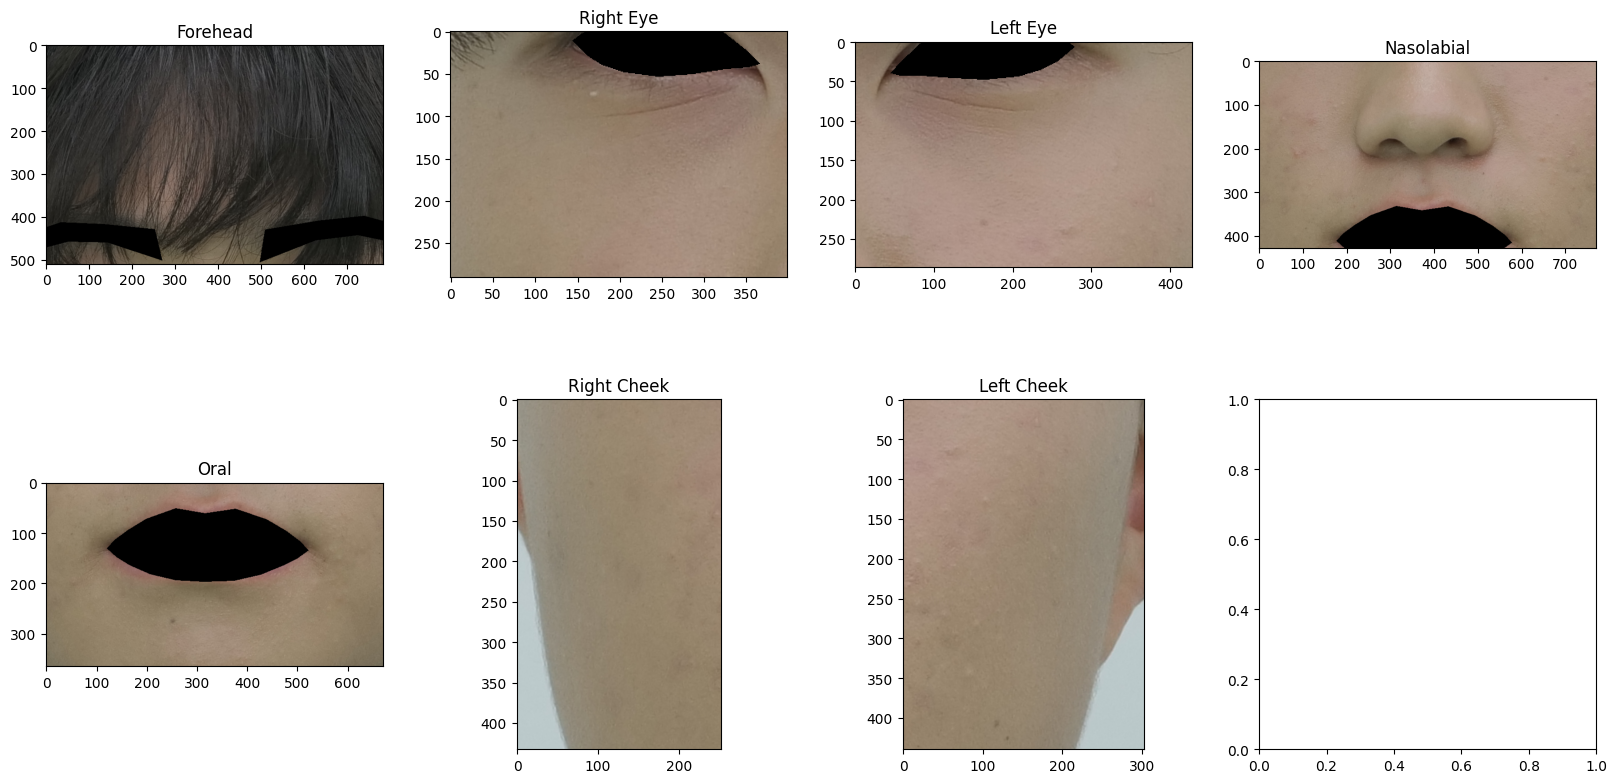

In [12]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes[0, 0].imshow(forehead)
axes[0, 0].set_title('Forehead')
axes[0, 1].imshow(right_eye)
axes[0, 1].set_title('Right Eye')
axes[0, 2].imshow(left_eye)
axes[0, 2].set_title('Left Eye')
axes[0, 3].imshow(nasolabial)
axes[0, 3].set_title('Nasolabial')
axes[1, 0].imshow(oral)
axes[1, 0].set_title('Oral')
axes[1, 1].imshow(right_cheek)
axes[1, 1].set_title('Right Cheek')
axes[1, 2].imshow(left_cheek)
axes[1, 2].set_title('Left Cheek')

plt.show()

### 028

In [1]:
import os

source_dir = '/home/work/hocheol_dir/workspace/datasets/_origin_data/028_data/data'
dest_dir = '/home/work/hocheol_dir/datasets/v0.2_data/wrinkle/028_data/data'

exts = set()
for root, dirs, files in os.walk(source_dir):
    for file in files:
        exts.add(file.split('.')[-1])

print(exts)

{'jpg'}


In [2]:
import pandas as pd
image_df = pd.DataFrame(os.listdir(source_dir), columns=['filename'])
paths = set()
for root, dirs, files in os.walk(source_dir):
    for file in files:
        if file.endswith('_F.jpg'):
            paths.add(os.path.join(root, file))

In [3]:
image_df = pd.DataFrame(list(paths), columns=['path'])
image_df['filename'] = image_df['path'].apply(lambda x: os.path.basename(x))
image_df.sort_values(by='filename', inplace=True, ignore_index=True)
image_df = image_df[['filename', 'path']]
image_df

,filename,path
0,0001_01_F.jpg,/home/work/hocheol_dir/workspace/datasets/_ori...
1,0001_02_F.jpg,/home/work/hocheol_dir/workspace/datasets/_ori...
2,0001_03_F.jpg,/home/work/hocheol_dir/workspace/datasets/_ori...
3,0002_01_F.jpg,/home/work/hocheol_dir/workspace/datasets/_ori...
4,0002_02_F.jpg,/home/work/hocheol_dir/workspace/datasets/_ori...
...,...,...
2890,1099_02_F.jpg,/home/work/hocheol_dir/workspace/datasets/_ori...
2891,1099_03_F.jpg,/home/work/hocheol_dir/workspace/datasets/_ori...
2892,1100_01_F.jpg,/home/work/hocheol_dir/workspace/datasets/_ori...
2893,1100_02_F.jpg,/home/work/hocheol_dir/workspace/datasets/_ori...


In [4]:
label_df = pd.read_csv('/home/work/hocheol_dir/workspace/datasets/v0.2_data/wrinkle/NIA_skin_measurement_wrinkle_250817 - 시트1.csv')
label_df.rename(columns={'periroal':'perioral'}, inplace=True)
merged_df = pd.merge(image_df, label_df, on='filename', how='inner')
merged_df['path'].apply(lambda x:os.path.exists(x)).value_counts()

path
True    2895
Name: count, dtype: int64

In [5]:
merged_df.head()

,filename,path,forehead,right_eye,left_eye,nasolabial,perioral,right_vol,left_vol
0,0001_01_F.jpg,/home/work/hocheol_dir/workspace/datasets/_ori...,2.0,2.0,2.0,3.0,2.0,2.0,2.0
1,0001_02_F.jpg,/home/work/hocheol_dir/workspace/datasets/_ori...,2.0,2.0,2.0,3.0,2.0,1.0,1.0
2,0001_03_F.jpg,/home/work/hocheol_dir/workspace/datasets/_ori...,3.0,2.0,2.0,3.0,2.0,2.0,2.0
3,0002_01_F.jpg,/home/work/hocheol_dir/workspace/datasets/_ori...,2.0,2.0,3.0,2.0,2.0,2.0,2.0
4,0002_02_F.jpg,/home/work/hocheol_dir/workspace/datasets/_ori...,2.0,2.0,2.0,2.0,2.0,2.0,2.0


In [6]:
import sys
sys.path.append("/home/work/hocheol_dir/workspace/datasets/v0.2_data/wrinkle")
from wrinkle_preprocess import wrinkle_preprocess
import cv2
import math
from tqdm import tqdm

sectors = ['forehead', 'right_eye', 'left_eye', 'nasolabial', 'perioral', 'right_vol', 'left_vol']
missed_data = set()

for i, row in tqdm(merged_df.iterrows(), total=len(merged_df)):
    path = row['path']
    values = wrinkle_preprocess(path)

    cropped_data = dict(zip(sectors, values))

    for sector, cropped_image in cropped_data.items():
        # print(sector)
        if math.isnan(row[sector]):
            # print(f"Skipping {sector} for {row['filename']} due to NaN value.")
            missed_data.add((sector, row['filename']))
            continue
        else:
            # print(sector, row[sector])
            cv2.imwrite(os.path.join(dest_dir, f"{sector}_{row['filename']}.jpg"), cropped_image)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1755415757.384073 2039513 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
  0%|          | 0/2895 [00:00<?, ?it/s]W0000 00:00:1755415757.407533 2039520 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1755415757.491294 2039523 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
100%|██████████| 2895/2895 [06:10<00:00,  7.81it/s]


In [13]:
# 라벨 없는 35개는 cropped하지 않음
len(missed_data) / 7

35.0

In [26]:
sectors

['forehead',
 'right_eye',
 'left_eye',
 'nasolabial',
 'perioral',
 'right_vol',
 'left_vol']

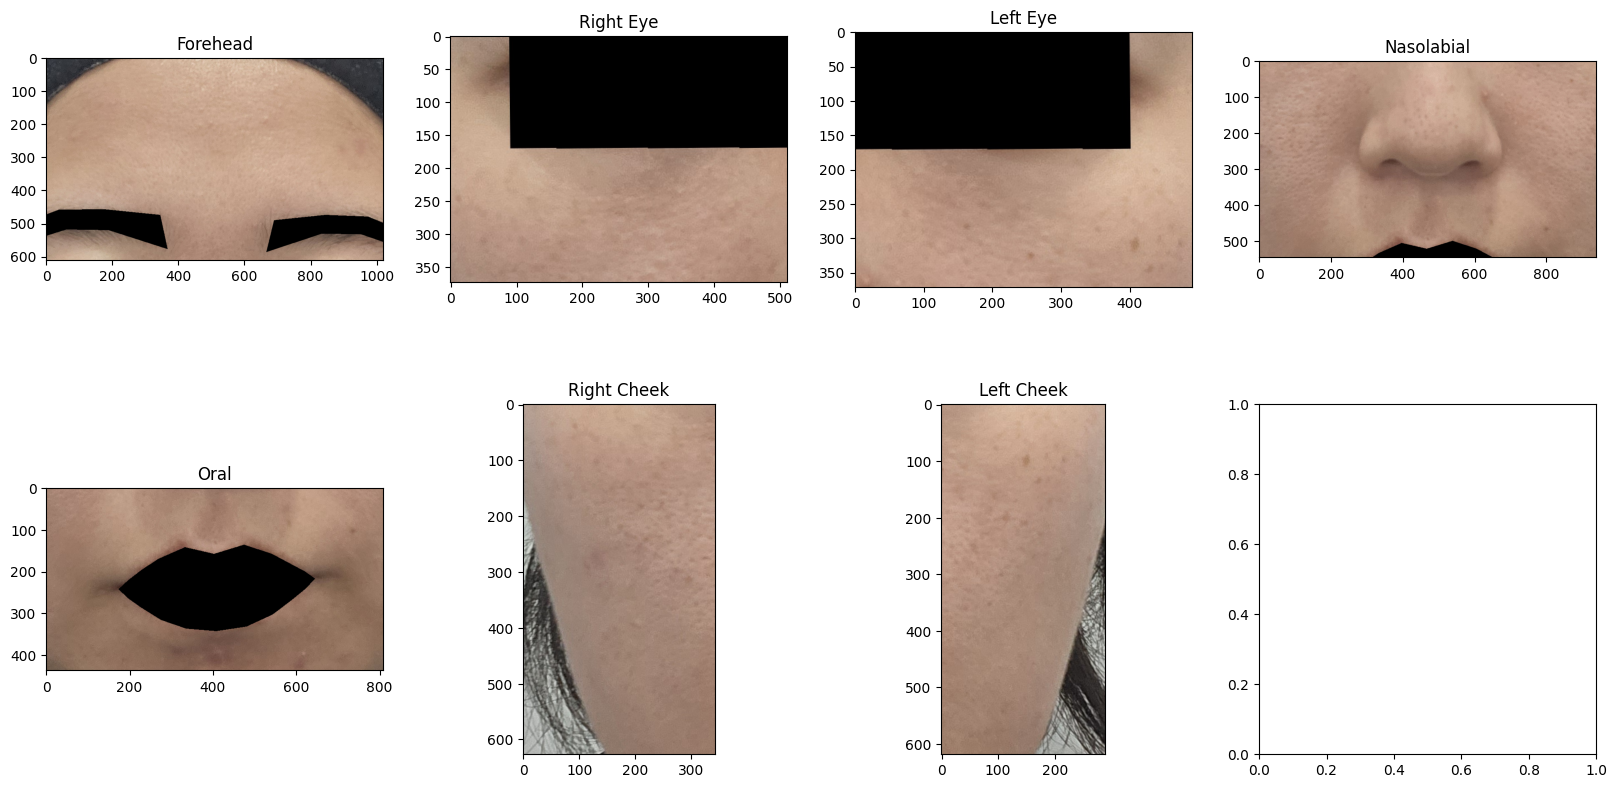

In [28]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes[0, 0].imshow(cv2.cvtColor(values[0], cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Forehead')
axes[0, 1].imshow(cv2.cvtColor(values[1], cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('Right Eye')
axes[0, 2].imshow(cv2.cvtColor(values[2], cv2.COLOR_BGR2RGB))
axes[0, 2].set_title('Left Eye')
axes[0, 3].imshow(cv2.cvtColor(values[3], cv2.COLOR_BGR2RGB))
axes[0, 3].set_title('Nasolabial')
axes[1, 0].imshow(cv2.cvtColor(values[4], cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('Oral')
axes[1, 1].imshow(cv2.cvtColor(values[5], cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Right Cheek')
axes[1, 2].imshow(cv2.cvtColor(values[6], cv2.COLOR_BGR2RGB))
axes[1, 2].set_title('Left Cheek')

plt.show()